# Preprocessing pipeline - single-subject pilot (cohort N=163)

### Goals:
1. Confirm a valid pilot subject (present in the 163-subject cohort, with both restEC and restEO recordings)
2. Load that subject's raw EEG data into MNE and verify channel inventory/types against the BIDS `_channels.tsv`
3. Implement and validate `bipolarEOG` and `apply_filters`, matching the authors' published order and parameters
4. Implement and validate `correct_EOG` (event-locked EOG regression)
5. Implement and validate artefact detection (seven threshold-based methods)
6. Implement epoching

### Inputs:
* Filtered cohort table from Day 4 (`data/cohort_filtered_n163.xlsx`)
* Raw TDBRAIN EEG data (BDF format) and BIDS sidecar files (`_channels.tsv`, `_eeg.json`) for the pilot subject

### Assumptions:
* This is a from-scratch reimplementation in MNE-Python of the authors' published preprocessing code (`autopreprocessing.py`, Brainclinics Foundation), which does not run on the current BDF/BIDS data format — as documented in the project README. Thresholds and parameters are taken directly from the authors' code, not approximated.
* The authors' `_channels.tsv` is treated as ground truth for channel names/types (resolves a naming discrepancy between the manuscript, which lists `HOHL`, and the authors' code, which lists `HPHL`, for the same channel)
* A single pilot subject is representative enough to validate pipeline logic before scaling to all 163 - this limits the ability to catch edge cases (e.g. missing channels, unusual noise) that batch processing will eventually surface

In [1]:
# Import libraries 
import numpy as np
import pandas as pd 
from pathlib import Path    
import mne
import matplotlib.pyplot as plt
import scipy.signal    
from scipy.stats import zscore                                                                                    

In [2]:
# load participants data from the filtered cohort Excel file

#define function to find repo root
def find_repo_root(marker = ".git"): # .git marks the repo root reliably regardless of who runs this or from where
    current_path = Path.cwd()
    for parent in [current_path, *current_path.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"Could not find {marker} in any parent directory of {current_path}")

project_root = find_repo_root()
data_dir = project_root / "data" 

TDBRAIN_participant_data = pd.read_excel(data_dir/"cohort_filtered_n163.xlsx")

#confirm that the data has been loaded correctly
print(TDBRAIN_participant_data.shape)

(163, 109)


In [3]:
## Get pilot subject data

#Choose pilot subject 
pilot_subject = TDBRAIN_participant_data.iloc[0]
pilot_subject_id = pilot_subject['TDBRAIN_ID']
print(pilot_subject_id)

#Construct the path to the pilot subject's EEG data file
pilot_subject_dir = data_dir / "TDBRAIN_Dataset_V3_1" / pilot_subject_id / "ses-1" / "eeg"
pilot_restEC_file = pilot_subject_dir / f"{pilot_subject_id}_ses-1_task-restEC_eeg.bdf"

#Existence check
assert pilot_restEC_file.exists(), f"File not found: {pilot_restEC_file}"

#Load the EEG data using MNE
raw_pilot_restEC = mne.io.read_raw_bdf(pilot_restEC_file, preload=True)

#check data against the 32-channel list from _channels.tsv
print(raw_pilot_restEC.ch_names)
print(len(raw_pilot_restEC.ch_names))
print(raw_pilot_restEC.info['sfreq'])
print(raw_pilot_restEC.get_channel_types())

#fix channel types based on the _channels.tsv file
new_types = {
    'VPVA': 'eog',
    'VNVB': 'eog',
    'HPHL': 'eog',
    'HNHR': 'eog',
    'Erbs': 'ecg',
    'Mass': 'emg'
}
#apply the new channel types
raw_pilot_restEC.set_channel_types(new_types)

#re-run the checks to confirm that the channel types have been updated
print(raw_pilot_restEC.get_channel_types())

sub-87999321
Extracting BDF parameters from /Users/romyweinstock/eeg-rtms-response-prediction/data/TDBRAIN_Dataset_V3_1/sub-87999321/ses-1/eeg/sub-87999321_ses-1_task-restEC_eeg.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 60499  =      0.000 ...   120.998 secs...
['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC3', 'FCz', 'FC4', 'T7', 'C3', 'Cz', 'C4', 'T8', 'CP3', 'CPz', 'CP4', 'P7', 'P3', 'Pz', 'P4', 'P8', 'O1', 'Oz', 'O2', 'VPVA', 'VNVB', 'HPHL', 'HNHR', 'Erbs', 'Mass', 'Status']
33
500.0
['eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'stim']
['eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eog', 'eog', 'eog', 'eog', 'ecg', 'emg', 'sti

**Goal 1 & 2 summary**
1. Valid pilot subject confirmed: `sub-87999321` (present in the 163-subject cohort, both restEC/restEO available)
2. Channel count/order matched `_channels.tsv` exactly; sampling rate confirmed at 500 Hz; the `Status` channel was an expected BDF addition not present in the sidecar file, correctly auto-typed as `stim`; channel types corrected for the six non-EEG physiological channels (`VPVA`/`VNVB`/`HPHL`/`HNHR` -> `eog`, `Erbs` -> `ecg`, `Mass` -> `emg`).

In [4]:
##Implement and validate `bipolarEOG` and `apply_filters`, matching the authors' published order and parameters

#Extract the four raw channels' data for the bipolar EOG calculation
eog_data = raw_pilot_restEC.get_data(picks=['VPVA', 'VNVB', 'HPHL', 'HNHR'])

#check the shape of the extracted data
print(eog_data.shape)  # Should be (4, n_samples)

#Compute the two derived signals 
VEOG = eog_data[0, :] - eog_data[1, :]  # Vertical EOG
HEOG = eog_data[2, :] - eog_data[3, :]  # Horizontal EOG

#Combine the derived signals into a single array
bipolar_eog_data = np.vstack((VEOG, HEOG))

#Build an Info object describing these two new channels
info = mne.create_info(ch_names=['VEOG', 'HEOG'], sfreq=raw_pilot_restEC.info['sfreq'], ch_types=['eog', 'eog'])

#Construct the RawArray from the stacked data and this Info
bipolar_eog = mne.io.RawArray(bipolar_eog_data, info)

#Merge it into the original Raw object
raw_pilot_restEC.add_channels([bipolar_eog], force_update_info=True)

(4, 60500)
Creating RawArray with float64 data, n_channels=2, n_times=60500
    Range : 0 ... 60499 =      0.000 ...   120.998 secs
Ready.


<RawBDF | sub-87999321_ses-1_task-restEC_eeg.bdf, 35 x 60500 (121.0 s), ~16.2 MiB, data loaded>

In [5]:
#Re-run the checks to confirm that the new channels have been added
print(raw_pilot_restEC.ch_names)   

#spot check the new channels' data  
eog_data_orig = raw_pilot_restEC.get_data(picks=['VPVA', 'VNVB', 'HPHL', 'HNHR'])
eog_data_bipolar = raw_pilot_restEC.get_data(picks=['VEOG', 'HEOG'])

sample_indices = [0, 30000, 60499]  # first, middle, last

for i in sample_indices:
    veog_expected = eog_data_orig[0, i] - eog_data_orig[1, i]  # VPVA - VNVB
    veog_actual = eog_data_bipolar[0, i]
    heog_expected = eog_data_orig[2, i] - eog_data_orig[3, i]  # HPHL - HNHR
    heog_actual = eog_data_bipolar[1, i]
    print(i, "VEOG match:", np.isclose(veog_expected, veog_actual), "| HEOG match:", np.isclose(heog_expected, heog_actual))


['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC3', 'FCz', 'FC4', 'T7', 'C3', 'Cz', 'C4', 'T8', 'CP3', 'CPz', 'CP4', 'P7', 'P3', 'Pz', 'P4', 'P8', 'O1', 'Oz', 'O2', 'VPVA', 'VNVB', 'HPHL', 'HNHR', 'Erbs', 'Mass', 'Status', 'VEOG', 'HEOG']
0 VEOG match: True | HEOG match: True
30000 VEOG match: True | HEOG match: True
60499 VEOG match: True | HEOG match: True


In [6]:
#Drop VPVA/VNVB/HPHL/HNHR
raw_pilot_restEC.drop_channels(['VPVA', 'VNVB', 'HPHL', 'HNHR'])
print(raw_pilot_restEC.ch_names)
print(len(raw_pilot_restEC.ch_names))

['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC3', 'FCz', 'FC4', 'T7', 'C3', 'Cz', 'C4', 'T8', 'CP3', 'CPz', 'CP4', 'P7', 'P3', 'Pz', 'P4', 'P8', 'O1', 'Oz', 'O2', 'Erbs', 'Mass', 'Status', 'VEOG', 'HEOG']
31


**`bipolarEOG` summary**

Computed `VEOG = VPVA - VNVB` and `HEOG = HPHL - HNHR` from the four raw EOG electrodes, matching the authors' `bipolarEOG` formula. Spot-checked the derived channels against the raw channels at three sample points (first, middle, last) using `np.isclose()` - all matched exactly. The original four raw EOG channels (`VPVA`/`VNVB`/`HPHL`/`HNHR`) were then dropped to match the authors' pipeline, which replaces rather than retains them. Final channel count: 31 (26 EEG, `Erbs`, `Mass`, `Status`, `VEOG`, `HEOG`).

In [7]:
# Demean the data (subtract each channel's own time-mean), matching the authors' demean() step.
# Applied after bipolarEOG and before apply_filters, per the authors' documented order.
# Uses MNE's type-based picks rather than positional slicing, since channel order in this
# object differs from the authors' fixed row layout - picks selects by channel type instead,
# reproducing their intent (EEG + EOG + ECG demeaned, EMG and stim excluded) robustly.

demean_picks = mne.pick_types(raw_pilot_restEC.info, eeg=True, eog=True, ecg=True, emg=False, stim=False)

data = raw_pilot_restEC.get_data(picks=demean_picks)
channel_means = data.mean(axis=1, keepdims=True)
demeaned_data = data - channel_means

raw_pilot_restEC._data[demean_picks, :] = demeaned_data

# Confirm each picked channel's mean is now ~0
print(raw_pilot_restEC.get_data(picks=demean_picks).mean(axis=1))

[-1.76167620e-19  1.16711049e-18  1.71763430e-18  7.63393022e-19
  2.64251431e-19 -2.34890161e-18 -9.17539690e-22  1.83507938e-20
  2.23879684e-19 -7.34031752e-20  3.57840479e-20  2.00023652e-19
 -1.87728621e-18 -1.52311589e-19  4.47759369e-19 -9.95530563e-20
  1.37630953e-19  1.90389486e-19 -2.34890161e-19  1.02764445e-18
  6.89989847e-19 -2.06446430e-19  5.30337941e-19  2.93612701e-20
 -7.59722863e-19  8.25785721e-20 -3.08293336e-19 -6.60628577e-19
  1.17445080e-19]


In [8]:
#Apply the filters in the order specified by the authors

#save original data for later comparison 
original_data = raw_pilot_restEC.copy()
#create a function to apply the filters in the specified order
def apply_filters(data, Fs, hpfreq, lpfreq, notchfreq, Q):
    # data: a single channel's 1D array, provided by MNE when this function 
    # is called via raw.apply_function() 
    b_notch, a_notch = scipy.signal.iirnotch(w0=notchfreq, Q=Q, fs=Fs)
    b_high, a_high = scipy.signal.butter(N=4, Wn=hpfreq/(Fs/2), btype='highpass')
    b_low, a_low = scipy.signal.butter(N=4, Wn=lpfreq/(Fs/2), btype='lowpass')

    data = scipy.signal.filtfilt(b_notch, a_notch, data)
    data = scipy.signal.filtfilt(b_high, a_high, data)
    data = scipy.signal.filtfilt(b_low, a_low, data)
    return data
#Apply the filters to the raw data using the specified parameters
raw_pilot_restEC.apply_function(
    apply_filters,
    picks= mne.pick_types(raw_pilot_restEC.info, eeg=True, eog=True, ecg=True, emg=True, stim=False), #Exclude the statues (stim) channels from filtering  
    channel_wise=True, #call function once per channel
    Fs=raw_pilot_restEC.info['sfreq'],
    hpfreq=0.5,
    lpfreq=100,
    notchfreq=50,
    Q=100
)

<RawBDF | sub-87999321_ses-1_task-restEC_eeg.bdf, 31 x 60500 (121.0 s), ~14.3 MiB, data loaded>

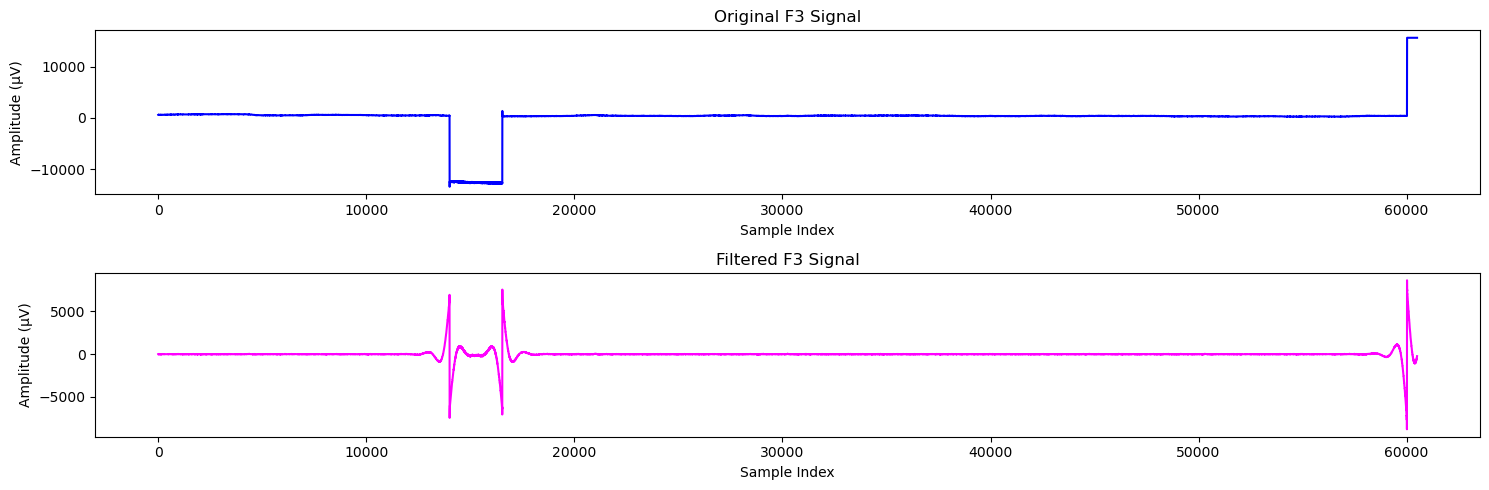

In [9]:
#Visual confirmation of the filtering effect on a sample EEG channel
channel_name = 'F3'  # Choose a channel to visualize
#Extract the original and filtered data for this channel
original_data_F3 = original_data.get_data(picks=[channel_name])[0] * 1e6
filtered_data_F3 = raw_pilot_restEC.get_data(picks=[channel_name])[0] * 1e6
#Plot the original and filtered signals for comparison
plt.figure(figsize=(15, 5))
plt.subplot(2, 1, 1)
plt.plot(original_data_F3, color='blue', label='Original F3')
plt.title('Original F3 Signal')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude (µV)')
plt.subplot(2, 1, 2)
plt.plot(filtered_data_F3, color='magenta', label='Filtered F3')
plt.title('Filtered F3 Signal')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude (µV)')
plt.tight_layout()
plt.show()

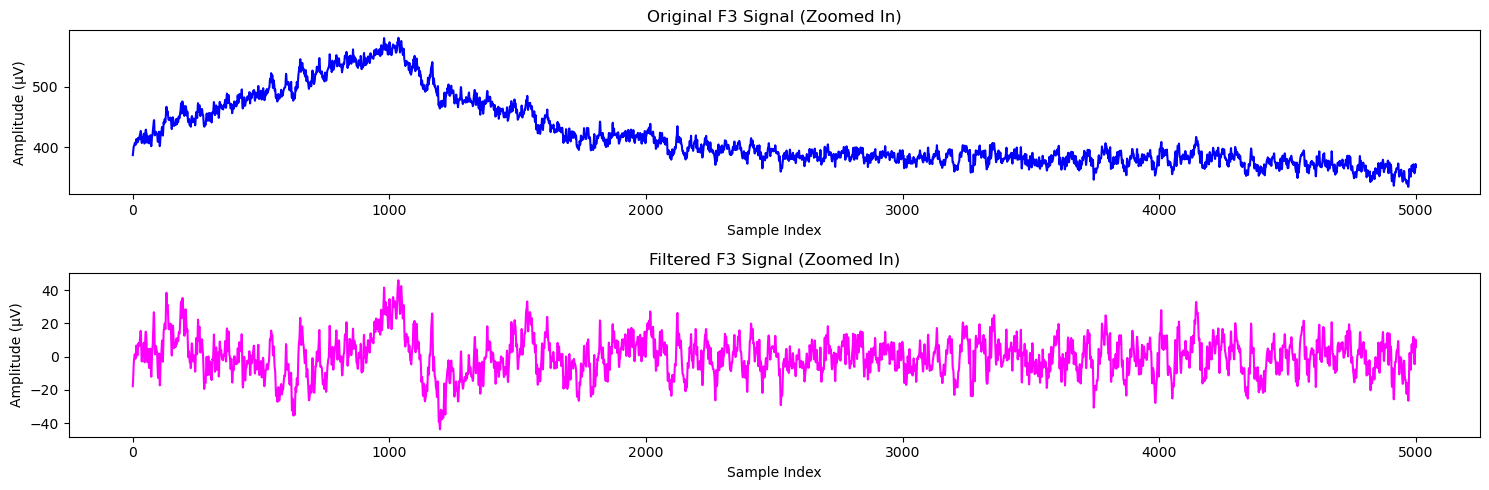

In [10]:
#zooming into a short, artefact-free stretch to visualize the filtering effect more clearly
start_sample = 20000
end_sample = 25000
plt.figure(figsize=(15, 5))
plt.subplot(2, 1, 1)
plt.plot(original_data_F3[start_sample:end_sample], color='blue', label='Original F3')
plt.title('Original F3 Signal (Zoomed In)')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude (µV)')
plt.subplot(2, 1, 2)
plt.plot(filtered_data_F3[start_sample:end_sample], color='magenta', label='Filtered F3')
plt.title('Filtered F3 Signal (Zoomed In)')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude (µV)')
plt.tight_layout()
plt.show()

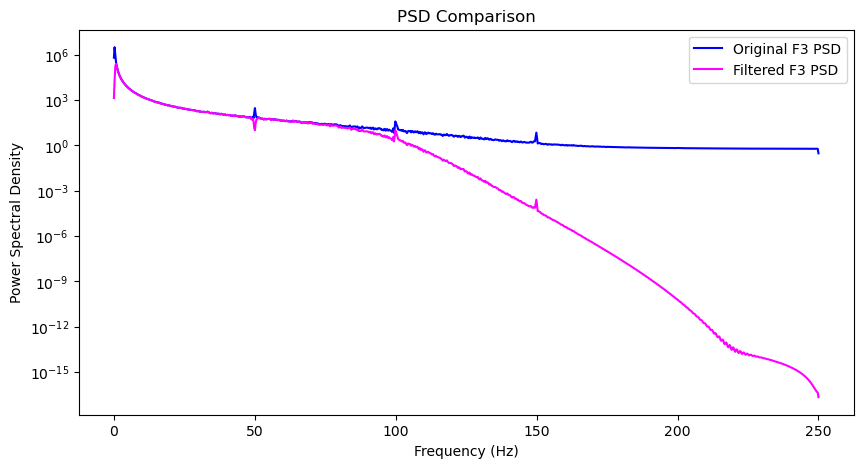

In [11]:
#validate the notch filter by checking the power spectral density (PSD) before and after filtering
#Compute the PSD of the original and filtered signals for the chosen channel
freqs_original, psd_original = scipy.signal.welch(original_data_F3, fs=raw_pilot_restEC.info['sfreq'], nperseg=2048)
freqs_filtered, psd_filtered = scipy.signal.welch(filtered_data_F3, fs=raw_pilot_restEC.info['sfreq'], nperseg=2048)

plt.figure(figsize=(10, 5))
plt.semilogy(freqs_original, psd_original, color='blue', label='Original F3 PSD')
plt.semilogy(freqs_filtered, psd_filtered, color='magenta', label='Filtered F3 PSD')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density')
plt.title('PSD Comparison')
plt.legend()
plt.show()


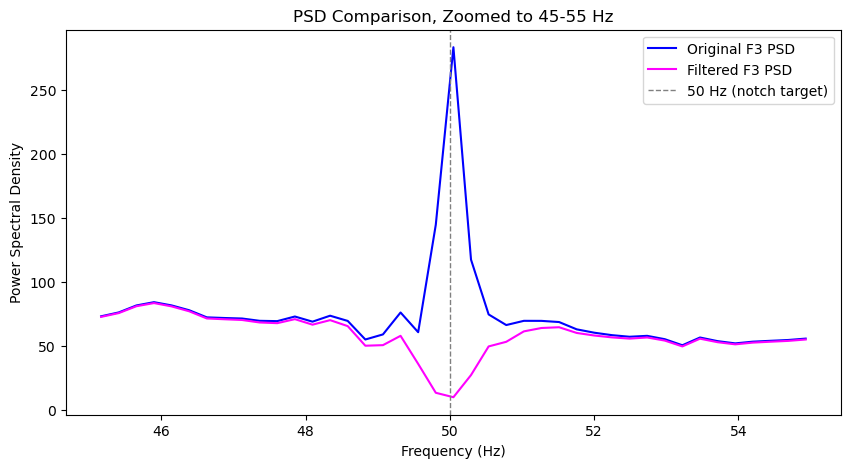

In [12]:
# Zoom into a narrow window around 50 Hz to check for the notch filter's effect directly.
# The notch filter (Q=100, notchfreq=50) has a bandwidth of ~50/100 = 0.5 Hz, so a broad
# 0-250 Hz view isn't fine-grained enough to see it clearly - this narrows the x-axis
# to 45-55 Hz specifically, where a working notch should show up as a sharp local dip.

freq_mask = (freqs_original >= 45) & (freqs_original <= 55)  # boolean mask for the frequency range of interest

plt.figure(figsize=(10, 5))
plt.plot(freqs_original[freq_mask], psd_original[freq_mask], color='blue', label='Original F3 PSD')
plt.plot(freqs_filtered[freq_mask], psd_filtered[freq_mask], color='magenta', label='Filtered F3 PSD')
# linear y-axis here, not semilogy — over this narrow a range, a linear scale makes
# a local dip easier to read than a log scale would
plt.axvline(50, color='gray', linestyle='--', linewidth=1, label='50 Hz (notch target)')  # reference line at the exact target frequency
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density')
plt.title('PSD Comparison, Zoomed to 45-55 Hz')
plt.legend()
plt.show()

**`apply_filters` validation summary**

Time-domain check on channel F3 confirmed the highpass filter removed the large DC offset (~-15 to −28 mV raw) and slow drift, leaving oscillatory signal in a physiologically plausible +-20–40 µV range. PSD comparison confirmed the lowpass filter suppressed power above ~100 Hz relative to the unfiltered signal. A zoomed PSD (45-55 Hz) confirmed the notch filter specifically suppresses the 50 Hz mains peak (~280 -> ~5 PSD units), with the dip localized to roughly 49-51 Hz, consistent with the `Q=100` setting. The 100 Hz and 150 Hz mains harmonics remain largely unfiltered, as expected as the authors' notch filter only targets 50 Hz, not its harmonics.

**Open item for artefact detection**

Three step-like discontinuities were visually identified in channel F3's raw signal during filter validation (two around samples ~14,000–16,500, one near the recording's end, ~sample 60,000). These produced sharp transient spikes in the filtered signal (an expected highpass response to a step discontinuity, not a filtering bug). Plausibly the kind of artefact the authors' `detect_jumps` method is designed to catch - not addressed in this notebook, flagged here so it isn't lost before artefact detection is implemented.

**Session status**

Goals 1-3 complete and validated on pilot subject `sub-87999321`:
1. Pilot subject confirmed (cohort member, both restEC/restEO available)
2. Channel inventory loaded and verified against `_channels.tsv`; types corrected
3. `bipolarEOG` and `apply_filters` implemented, matching the authors' published order and parameters; both validated (spot-check for bipolarEOG, time-domain + PSD checks for apply_filters)

Not yet started: goal 4 (`correct_EOG`), goal 5 (artefact detection), goal 6 (epoching).

In [13]:
## Correct EOG using athours method adapted from (Gratton et al. 1999)

#Artefact segment detection in VEOG
#Lowpass filter (15 Hz) 
VEOG_channel = raw_pilot_restEC.get_data(picks= 'VEOG')
Fs = raw_pilot_restEC.info['sfreq'] 
nyq = Fs*0.5
normal_cutoff = 15/nyq
b_l, a_l = scipy.signal.butter(4, normal_cutoff, btype='lowpass', analog=False)
VEOG_channel_filtered = scipy.signal.filtfilt(b_l, a_l, VEOG_channel) 
#Get the analytical signal using Hilbert transform
VEOG_1d = VEOG_channel_filtered[0]
n_samples = len(VEOG_1d)  # original length, before padding
N_pad = int(len(VEOG_1d) + len(VEOG_1d)*0.2)
VEOG_hil = scipy.signal.hilbert(VEOG_1d.copy(), N=N_pad, axis=-1)
VEOG_hilb = VEOG_hil[:n_samples]
amplenv = np.abs(VEOG_hilb)

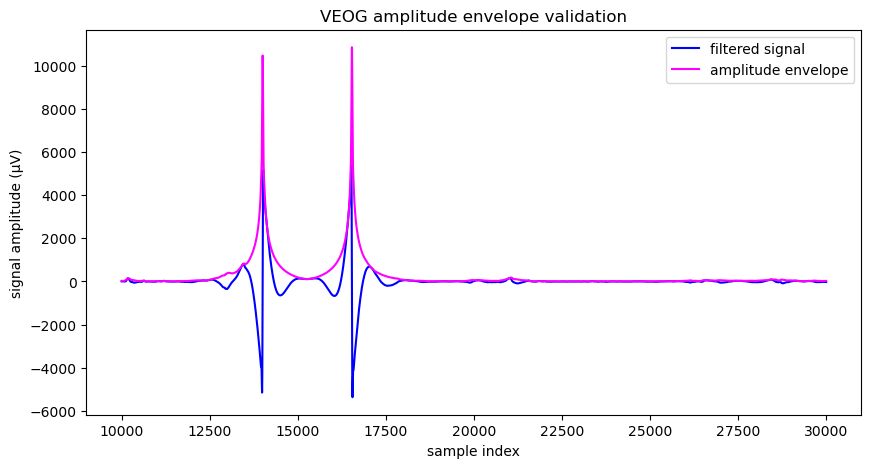

In [22]:
#Visual confirmation of VEOG amplitude envelope extraction
fig = plt.figure(figsize=(10,5))
start_sample = 10000
end_sample = 30000
sample_range = range(start_sample, end_sample)

plt.plot(sample_range, VEOG_1d[start_sample:end_sample] * 1e6, color='blue', label='filtered signal')
plt.plot(sample_range, amplenv[start_sample:end_sample] * 1e6, color='magenta', label='amplitude envelope')
plt.xlabel('sample index')
plt.ylabel('signal amplitude (µV)')
plt.title('VEOG amplitude envelope validation')
plt.legend()
plt.show()

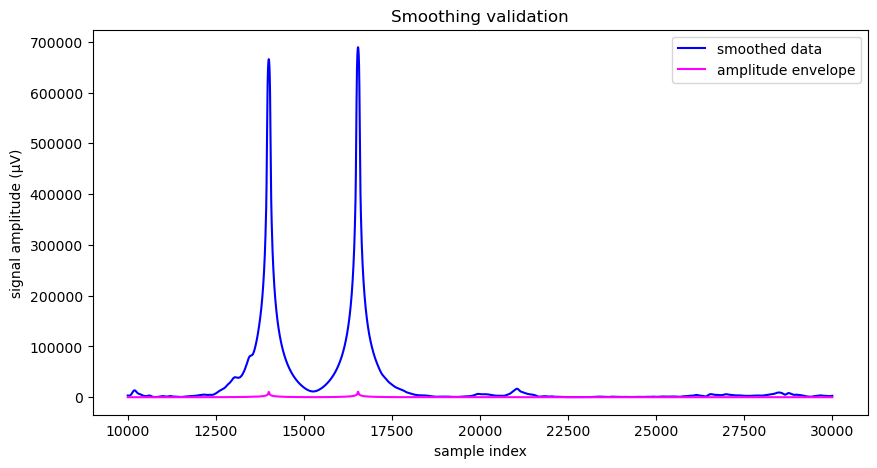

In [25]:
#Smoothing amplitude envelope with boxcar convolution
boxdata = scipy.signal.convolve(amplenv, scipy.signal.windows.boxcar(int(0.2*Fs)), mode ='same', method ='direct')
#visual confirmation of smoothed data 
fig = plt.figure(figsize=(10,5))
start_sample = 10000
end_sample = 30000
sample_range = range(start_sample, end_sample)

plt.plot(sample_range, boxdata[start_sample:end_sample] * 1e6, color='blue', label='smoothed data')
plt.plot(sample_range, amplenv[start_sample:end_sample] * 1e6, color='magenta', label='amplitude envelope')
plt.xlabel('sample index')
plt.ylabel('signal amplitude (µV)')
plt.title('Smoothing validation')
plt.legend()
plt.show()

## VEOG artefact-segment detection: signal preparation summary

Implemented the three-stage signal preparation used by the authors' `correct_EOG` method (Gratton et al., 1983/1999) as the input to threshold-based artefact detection, matching their published parameters:

1. **Lowpass filter (15 Hz)**: 4th-order Butterworth, applied via `scipy.signal.filtfilt` (zero-phase), isolating slow, blink-relevant frequency content from VEOG and excluding higher-frequency noise.
2. **Hilbert transform -> amplitude envelope**: computed the analytic signal via `scipy.signal.hilbert`, using 20% FFT padding to push edge-discontinuity artefacts (arising from the FFT's implicit periodicity assumption) out of the signal before truncating back to the original length. The envelope (`amplenv`) was obtained via `np.abs()` of the resulting complex-valued analytic signal.
3. **Boxcar smoothing**: convolved the envelope with an unnormalised 100-sample (200 ms) boxcar window (`scipy.signal.windows.boxcar`) to reduce sample-to-sample jitter, producing `boxdata`.

**Validation**: overlaid plots at each stage confirmed correct behaviour - the amplitude envelope traced the outer boundary of the filtered VEOG waveform without dipping below zero or crossing inside the waveform; the boxcar-smoothed version preserved the same peak locations and overall shape as the unsmoothed envelope, with visibly reduced jitter.

**Design note**: `boxdata` is on a substantially different amplitude scale to `amplenv` (~100x larger), since `scipy.signal.windows.boxcar` produces an unnormalised window (a moving sum, not a moving average) - this matches the authors' implementation exactly and does not affect the downstream z-score thresholding step, since z-scoring is invariant to positive linear scaling.

**Deviations from authors' code** (library version compatibility, no change in method):
- `np.int` -> `int()` (deprecated in current NumPy)
- `scipy.signal.boxcar` -> `scipy.signal.windows.boxcar` (relocated in current SciPy)

In [29]:
## Z-score thresholding to flag VEOG artefact samples

zdata = zscore(boxdata)
threshold = 0.2  # vthreshold, per authors' correct_EOG default

# One-sided threshold (deviation from authors' code) - see markdown below for rationale
Asamps = np.where(zdata > threshold)[0]

# Check the flagged fraction as a sanity check
flagged_fraction = len(Asamps) / len(boxdata)
print(f"Flagged samples: {len(Asamps)} / {len(boxdata)} ({flagged_fraction:.2%})")

Flagged samples: 5258 / 60500 (8.69%)


In [30]:
## Diagnostic: why the authors' two-sided condition was rejected

# Compare one-sided vs two-sided flagging to confirm the skew issue
flagged_high = np.where(zdata > threshold)[0]
flagged_low = np.where(zdata < -threshold)[0]
print(f"Positive-side flags: {len(flagged_high)}")
print(f"Negative-side flags: {len(flagged_low)}")
print(f"boxdata mean: {boxdata.mean():.4f}, std: {boxdata.std():.4f}")

Positive-side flags: 5258
Negative-side flags: 40581
boxdata mean: 0.0143, std: 0.0576


## VEOG z-score thresholding: deviation from authors' two-sided condition

The authors' `_detect_artifact` uses a two-sided z-score condition (`|zdata| > threshold`) to flag artefact samples. Applying this directly to `boxdata` at the authors' default `vthreshold = 0.2` flagged 75.8% of the recording as artefact, implausible given only two visually-confirmed blink events in this pilot subject's 2-minute recording.

**Diagnosis**: `boxdata` is non-negative by construction (derived from `np.abs()` of the Hilbert-transformed VEOG, then boxcar-convolved with a non-negative window). Its distribution is heavily right-skewed: mean (0.0143) < std (0.0576), driven by a small number of large blink-related peaks against a long, low-amplitude baseline. Z-scoring this skewed, always-positive signal pushes ordinary baseline samples to z = ~-0.25, which false-flags them under the negative-side condition (40,581 of the 46,000 flagged samples came from the negative side alone; only 5,258 came from genuine positive excursions).

**Resolution**: since `boxdata` cannot be meaningfully "artefactual" in the negative direction (a low envelope value simply means no eye movement, not a distinct artefact type), a one-sided threshold (`zdata > threshold`) was used instead. This is treated as a justified deviation from the authors' code rather than a silent fix, consistent with this project's approach of treating the authors' implementation as reference methodology rather than unquestioned ground truth (see also: the `.edf` docstring/code mismatch noted in `loaddata()`). With the one-sided condition, 8.69% of samples were flagged - consistent with the two blink events visible in exploratory plots.

In [34]:
#collapsing flagged samples (`Asamps`) into contiguous artefact segments (start/end sample pairs)
segments = []
begin = Asamps[0] #style simplification of the author's vstack-placeholder pattern

for e in range(len(Asamps)):
    if e >= len(Asamps)-1:
        end = Asamps[-1]
        segments.append([begin, end])
    elif Asamps[e+1] == Asamps[e]+1:
        continue
    else:
        end = Asamps[e]
        segments.append([begin, end])
        begin = Asamps[e+1]

Atrl = np.array(segments, dtype=int)
print(f'Number of segments: {Atrl.shape[0]}')
print(f'Segment boundaries:\n{Atrl}')

Number of segments: 3
Segment boundaries:
[[12851 14889]
 [15638 17480]
 [59117 60492]]


/var/folders/sj/n3g071kn3k5d875m963jywkr0000gn/T/ipykernel_7895/4289862780.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


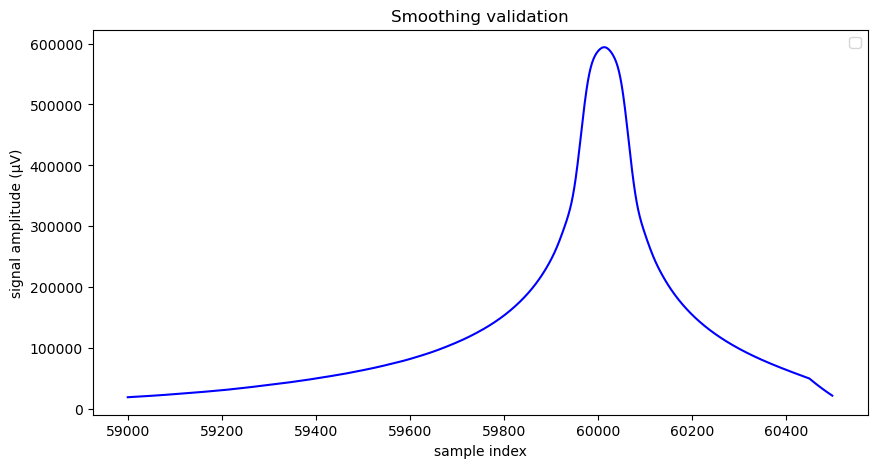

In [37]:
#visually inspect third segment 
#plot the boxdata in the window around sample 59000-60500 
#Smoothing amplitude envelope with boxcar convolution
boxdata = scipy.signal.convolve(amplenv, scipy.signal.windows.boxcar(int(0.2*Fs)), mode ='same', method ='direct')
#visual confirmation of smoothed data 
fig = plt.figure(figsize=(10,5))
start_sample = 59000
end_sample = 60500
sample_range = range(start_sample, end_sample)

plt.plot(sample_range, boxdata[start_sample:end_sample] * 1e6, color='blue')
plt.xlabel('sample index')
plt.ylabel('signal amplitude (µV)')
plt.title('Smoothing validation')
plt.legend()
plt.show()

### Open items (artefact detection, deferred)

- Three step-like discontinuities in F3 (identified during `apply_filters` validation): two near samples ~14,000-16,500, one near the recording's end (~sample 60,000).
- A third VEOG artefact segment (59117-60492, detected via z-score thresholding) has a peak location closely coinciding with the F3 discontinuity near sample 60,000, and sits at the very edge of the recording where filter/Hilbert-transform edge effects are more likely. Plausibly the same underlying event (non-ocular) rather than a genuine blink, or a filtering edge artefact - not yet distinguishable from the enveloped signal alone. To be resolved once jump/step-artefact detection (a separate, later goal) is implemented; until then this segment is retained in `Atrl` unmodified.

In [ ]:
## Segment padding
## Extends each detected artefact segment proportionally to its own length,
## to capture the gradual rise/fall the threshold-crossing missed at the edges.

# Step 1: create a per-sample "artefact map" for the whole recording, all zeros to start.
artsamples = np.zeros(len(boxdata), dtype=int)

# Step 2: padding fraction - each segment gets extended by 30% of its own width,
# on both sides, per the authors' vpadding default.
padding = 0.3

# Step 3: only do this if segments were actually detected
if len(Atrl) > 0:
    # Step 4: loop over every detected segment (each row of Atrl is one [begin, end] pair)
    for i in range(Atrl.shape[0]):

        # Case A: this segment starts right at sample 0 (the very beginning of the recording)
        if Atrl[i, 0] == 0:
            pad_amount = int((Atrl[i, 1] - 0) * padding)
            artsamples[0 : Atrl[i, 1] + pad_amount] = 1

        # Case B: this segment ends at the very last sample of the recording
        elif Atrl[i, 1] == len(artsamples):
            pad_amount = int((Atrl[i, 1] - Atrl[i, 0]) * padding)
            artsamples[Atrl[i, 0] - pad_amount : len(artsamples)] = 1

        # Case C: general case - segment is somewhere in the middle, pad both sides
        else:
            pad_amount = int((Atrl[i, 1] - Atrl[i, 0]) * padding)
            artsamples[Atrl[i, 0] - pad_amount : Atrl[i, 1] + pad_amount] = 1

False
60904


False
60904
Samples flagged before padding (from Atrl): 5255
Samples flagged after padding: 7587


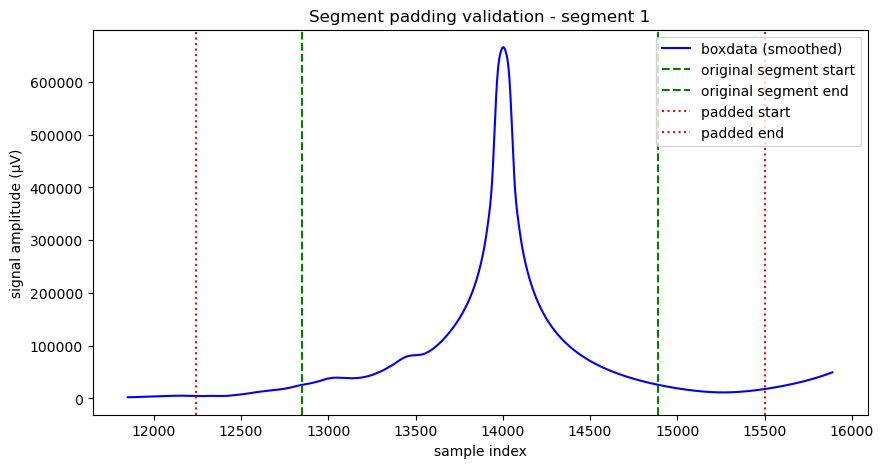

In [44]:
##Validation 
print(Atrl[2,1] == len(artsamples))  # confirm which case it took
print(Atrl[2,1] + int((Atrl[2,1]-Atrl[2,0])*0.3))  
print(f"Samples flagged before padding (from Atrl): {sum(end-begin for begin,end in Atrl)}")
print(f"Samples flagged after padding: {artsamples.sum()}")

## Visual check: segment 1, original vs padded boundaries

segment_1_start = Atrl[0,0]
segment_1_end = Atrl[0,1]

# padded boundaries, recomputed the same way as in the padding loop above
pad_amount_1 = int((segment_1_end - segment_1_start) * padding)
padded_start_1 = segment_1_start - pad_amount_1
padded_end_1 = segment_1_end + pad_amount_1

# add margin so the padded region is actually visible in the plot
margin = 1000
plot_start = segment_1_start - margin
plot_end = segment_1_end + margin
x = np.arange(plot_start, plot_end)

fig = plt.figure(figsize=(10,5))
plt.plot(x, boxdata[plot_start:plot_end] * 1e6, color='blue', label='boxdata (smoothed)')
plt.axvline(segment_1_start, color='green', linestyle='--', label='original segment start')
plt.axvline(segment_1_end, color='green', linestyle='--', label='original segment end')
plt.axvline(padded_start_1, color='red', linestyle=':', label='padded start')
plt.axvline(padded_end_1, color='red', linestyle=':', label='padded end')
plt.xlabel('sample index')
plt.ylabel('signal amplitude (µV)')
plt.title('Segment padding validation - segment 1')
plt.legend()
plt.show()


## Segment padding

Extended each detected VEOG artefact segment proportionally to its own width (30%, per authors' `vpadding` default), on both sides, to capture the gradual rise/fall of the envelope that simple threshold-crossing misses at the segment edges. Implemented as a per-sample binary map (`artsamples`), following the authors' three-case structure (segment touching the recording start, segment touching the recording end, general case).

**Validation**:
- Total flagged samples increased from 5,255 (pre-padding, from `Atrl`) to 7,587 (post-padding, `artsamples.sum()`) - consistent with proportional padding on three segments.
- Visual check on segment 1 (original boundaries 12851-14889) confirmed the padded boundaries extend sensibly into the envelope's low-amplitude shoulders on both sides, without overreaching into baseline or adjacent segments.

**Corrected bug (authors' code)**: the authors' first-branch (segment starting at sample 0) referenced `Atrl[0,1]` instead of `Atrl[i,1]` - a hardcoded reference to the first segment regardless of which segment `i` was actually being processed. Corrected to `Atrl[i,1]`.

**Noted fragility (authors' code, not corrected)**: the boundary check for "segment ends at the recording's final sample" uses exact equality (`Atrl[i,1] == len(artsamples)`). Segment 3 ends at sample 60492, 8 samples short of the recording's actual length (60500), so it narrowly missed this check and fell through to the general (both-sides-padding) case instead. The resulting padding request (up to sample 60904) exceeded the recording length; NumPy's slice-assignment silently clipped this to the array's actual end, producing the same correct result the boundary case would have given, but via an unintended path. Not corrected, since the practical output is unaffected here, but flagged as a brittleness in could behave differently under other data.

In [52]:
#re-deriving clean start/end segment pairs from the padded `artsamples` array 
# (needed before the regression step, since padded segments may now overlap).
starts = np.where(np.diff(artsamples) == 1)[0] + 1
ends = np.where(np.diff(artsamples) == -1)[0] + 1

# handle the edge case: recording ends while still inside an artefact
if artsamples[-1] == 1:
    ends = np.append(ends, len(artsamples))

# (for completeness, the mirror case - recording starts inside an artefact)
if artsamples[0] == 1:
    starts = np.insert(starts, 0, 0)
# stack them column-wise into a 2D array matching Atrl's [begin, end]
Atrl_padded = np.column_stack((starts, ends))
print(Atrl_padded.shape) #confirm 
#check if segment 1 and two got merged (2 artefacts and not 3):
print(Atrl_padded)


(2, 2)
[[12240 18032]
 [58705 60500]]


## Re-deriving contiguous segments from padded artefact map

Converted the per-sample `artsamples` binary map back into `[begin, end]` segment pairs using `np.diff` to detect 0->1 (start) and 1->0 (end) transitions, handling the edge case where the recording ends while still inside an artefact (segment 3's padding, clipped at the recording boundary - see prior note) by explicitly appending the final sample index.

**Result**: padding collapsed the original 3 segments into 2. Segments 1 and 2 (originally 12851-14889 and 15638-17480) had padded boundaries that overlapped (padded end of segment 1 = ~15495, padded start of segment 2 = ~15085), merging them into a single artefact window (12240-18032). Segment 3 remains separate (58705-60500, clipped at the recording's end).

This is the expected/intended behaviour of proportional padding on closely-spaced segments, and is why the per-sample `artsamples` representation was used rather than manually adjusting `[begin, end]` pairs - it handles overlap-driven merging automatically via the same contiguous-run-detection logic already validated in the earlier thresholding step, rather than requiring separate merge-handling code.

**Result**: `Atrl_padded` = `[[12240, 18032], [58705, 60500]]` - the final artefact segments to be used for the regression step.